In [ ]:
import numpy as np
import pandas as pd
from hiprof.base.graph import Graph
from hiprof.verification.falsifier import HPFalsifier

Consider the following ADMGs (Wienöbst et al., 2024):

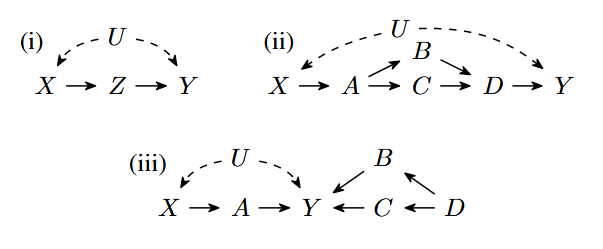
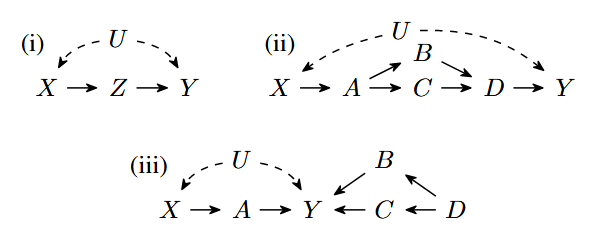
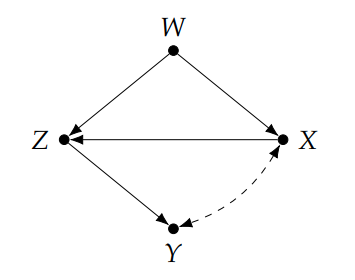

### ADMG (i)

In [ ]:
nodes = ["X", "Z", "Y"]
directed = pd.DataFrame(
    [[0, 1, 0],
     [0, 0, 1],
     [0, 0, 0]],
    index=nodes,
    columns=nodes,
)
bidirected = pd.DataFrame(
    [[0, 0, 1],
     [0, 0, 0],
     [1, 0, 0]],
    index=nodes,
    columns=nodes,
)
graph = Graph(directed=directed, bidirected=bidirected)

In [ ]:
# Front-door criterion
formula = "INT_{Z} { p(Z | X=.) INT_{X} { p(Y | X, Z) p(X) } }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

In [ ]:
formula = "p(Y | X=.)"
falsifier.check(formula)

### ADMG (ii)

In [ ]:
nodes = ["X", "A", "B", "C", "D", "Y"]
directed = pd.DataFrame(
    [[0, 1, 0, 0, 0, 0],
     [0, 0, 1, 1, 0, 0],
     [0, 0, 0, 0, 1, 0],
     [0, 0, 0, 0, 1, 0],
     [0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0]],
    index=nodes,
    columns=nodes,
)
bidirected = pd.DataFrame(
    np.zeros((len(nodes), len(nodes))),
    index=nodes,
    columns=nodes,
)
bidirected.loc["X", "Y"] = 1
bidirected.loc["Y", "X"] = 1
graph = Graph(directed=directed, bidirected=bidirected)

In [ ]:
formula = "INT_{A} { p(A | X=.) INT_{X} { p(Y | X, A) p(X) } }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

In [ ]:
formula = "INT_{A, B, C, D} { p(A, B, C, D | X=.) INT_{X} { p(Y | X, A, B, C, D) p(X) } }"
falsifier.check(formula)

In [ ]:
# C is not enough to block the path
formula = "INT_{C} { p(C | X=.) INT_{X} { p(Y | X, C) p(X) } }"
falsifier.check(formula)

### ADMG (iii)

While both $\{A, B, C\}$ and $\{A\}$ are FD sets, neither $\{A, B\}$ nor $\{A, C\}$ nor $\{B, C\}$ satisfy the FD criterion.

In [ ]:
nodes = ["X", "A", "Y", "B", "D", "C"]
directed = pd.DataFrame(
    [[0, 1, 0, 0, 0, 0],
     [0, 0, 1, 0, 0, 0],
     [0, 0, 0, 0, 0, 0],
     [0, 0, 1, 0, 0, 0],
     [0, 0, 0, 1, 0, 1],
     [0, 0, 1, 0, 0, 0]],
    index=nodes,
    columns=nodes,
)
bidirected = pd.DataFrame(
    np.zeros((len(nodes), len(nodes))),
    index=nodes,
    columns=nodes,
)
bidirected.loc["X", "Y"] = 1
bidirected.loc["Y", "X"] = 1
graph = Graph(directed=directed, bidirected=bidirected)

$\{A, B, C\}$

In [ ]:
formula = "INT_{A, B, C} { p(A, B, C | X=.) INT_{X} { p(Y | X, A, B, C) p(X) } }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

$\{A\}$

In [ ]:
formula = "INT_{A} { p(A | X=.) INT_{X} { p(Y | X, A) p(X) } }"
falsifier.check(formula)

$\{A, B\}$

In [ ]:
formula = "INT_{A, B} { p(A, B | X=.) INT_{X} { p(Y | X, A, B) p(X) } }"
falsifier.check(formula)

$\{A, C\}$

In [ ]:
formula = "INT_{A, C} { p(A, C | X=.) INT_{X} { p(Y | X, A, C) p(X) } }"
falsifier.check(formula)

$\{B, C\}$

In [ ]:
formula = "INT_{B, C} { p(B, C | X=.) INT_{X} { p(Y | X, B, C) p(X) } }"
falsifier.check(formula)

$\{A, D\}$

In [ ]:
formula = "INT_{A, D} { p(A, D | X=.) INT_{X} { p(Y | X, A, D) p(X) } }"
falsifier.check(formula)

So $\{A, B\}$ and $\{A, C\}$ are not FD sets but can actually be used to identify the causal effect from $X$ to $Y$ using the FD adjustment formula.

Consider now the following ADMG:

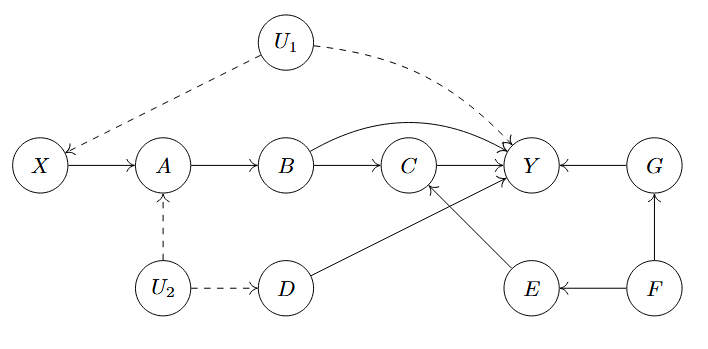

A set of variables $Z$ satisfies the front-door criterion relative to an ordered pair of variables $(X,Y)$ in a DAG $G$ if:
1) $Z$ intercepts all directed paths from $X$ to $Z$,
2) there is no unblocked back-door path from $X$ to $Z$,
3) all back-door paths from $Z$ to $Y$ are blocked by $X$.

In this example, there are $3$ FD sets. FD sets should contain either $B$ or $A$. If $A\in Z$ there is a back-door path $A\leftarrow U_2 \rightarrow D \rightarrow Y$ that is blocked by $D$. Analogously, if $B\in Z$, there is a backdoor path $B\leftarrow A\leftarrow U_2 \rightarrow D \rightarrow Y$ that is blocked by $D$. Therefore, the FD sets are $\{A, D\}$, $\{B, D\}$ and $\{A, B, D\}$.

However, we can find several sets that are not FD sets but that satisfy the front-door formula: $$p(y|do(x))=\sum_z p(z|x)\sum_{x'}p(y|x',z)p(x').$$
For example, if we also include $C$ in each set, we need to include at least one among $\{E, F, G\}$. If we do this, we and up with a set that has a backdoor path to $Y$ that is not blocked by $X$. Therefore, the resulting set is not an FD set per se.
We could also not include $C$ but still have at least one among $\{E, F, G\}$.

In [ ]:
nodes = ["X", "A", "B", "C", "Y", "D", "E", "F", "G"]
directed = pd.DataFrame(
    np.zeros((len(nodes), len(nodes))),
    index=nodes,
    columns=nodes,
)
directed.loc["X", "A"] = 1
directed.loc["A", "B"] = 1
directed.loc["B", "C"] = 1
directed.loc["B", "Y"] = 1
directed.loc["C", "Y"] = 1
directed.loc["D", "Y"] = 1
directed.loc["E", "C"] = 1
directed.loc["F", "E"] = 1
directed.loc["F", "G"] = 1
directed.loc["G", "Y"] = 1
bidirected = pd.DataFrame(
    np.zeros((len(nodes), len(nodes))),
    index=nodes,
    columns=nodes,
)
bidirected.loc["X", "Y"] = 1
bidirected.loc["Y", "X"] = 1
bidirected.loc["A", "D"] = 1
bidirected.loc["D", "A"] = 1
graph = Graph(directed=directed, bidirected=bidirected)

First, we check that $\{A\}$ and $\{B\}$ can't be used for the FD criterion.

In [ ]:
formula = "INT_{A} { p(A | X=.) INT_{X} { p(Y | X, A) p(X) } }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

In [ ]:
formula = "INT_{B} { p(B | X=.) INT_{X} { p(Y | X, B) p(X) } }"
falsifier.check(formula)

We now list all the sets that could still use the FD identification formula even though they are not FD sets (because one of the criteria is violated) and see if they pass the check.

In [ ]:
sets = [
    ["A", "D", "C"],
    ["A", "D", "E"],
    ["B", "D", "E"],
    ["B", "D", "F"],
    ["A", "D", "G"],
    ["B", "D", "G"],
    ["A", "D", "C", "E"],
    ["B", "D", "C", "E"],
    ["A", "D", "C", "F"],
    ["A", "D", "C", "G"],
    ["A", "B", "D", "E"],
    ["A", "B", "D", "G"],
    ["A", "B", "D", "C", "E"],
    ["A", "D", "C", "E", "F"],
    ["A", "B", "D", "C", "E"],
    ["A", "D", "C", "E", "G"],
    ["A", "D", "C", "F", "G"],
]

In [ ]:
ver = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
for var_list in sets:
    vars = ", ".join(var_list)
    formula = f"INT_{{{vars}}} {{ p({vars} | X=.) INT_{{X}} {{ p(Y | X, {vars}) p(X) }} }}"
    ret = falsifier.check(formula)
    print(f"[{vars}]: {ret[0]}")